# Lecture 2: Data Wrangling, Git, and Tabular Data


:::{admonition} Learning Objectives
:class: tip
After this lecture, you will be able to:
- Use Git for version control in a data science workflow
- Load, inspect, and clean tabular data with pandas {cite}`mckinney2010pandas`
- Reshape data into a *tidy* format {cite}`wickham2014tidy` and perform common wrangling operations (filtering, grouping, joining)
- Handle missing values and duplicates systematically {cite}`little2019statistical`
- Move fluently between pandas, SQL, and Polars, and choose appropriate storage formats (CSV vs Parquet)
:::

This lecture builds on the setup and Python primer from [Lecture 1](lecture_1.md) and prepares the ground for [Lecture 3](lecture_3.ipynb) on data retrieval. The material follows the applied workflow described in *R for Data Science* {cite}`wickham2023r4ds` and the software-engineering practices recommended by {cite}`wilson2017good` and {cite}`kernighan1999practice`.

:::{note}
This notebook imports from the `fun_ds` package. To run the cells, clone the
repository and follow the setup instructions on the [home page](/intro).
:::

## Table of Contents

- [Data quality dimensions](#data-quality-dimensions)
- [Version control with Git](#version-control-with-git)
- [Data wrangling: definition and motivation](#data-wrangling-definition-and-motivation)
- [Tidy data (wide vs long)](#tidy-data-wide-vs-long)
- [Core DataFrame operations](#core-dataframe-operations)
- [Missing values (nulls)](#missing-values-nulls)
- [Strings, regex, and dates](#strings-regex-and-dates)
- [Joining / merging tables](#joining-merging-tables)
- [SQL for tabular data](#sql-for-tabular-data-runnable-with-sqlite3)
- [Polars (optional)](#polars-optional)
- [Data formats: CSV vs Parquet](#data-formats-csv-vs-parquet)

An [Exercises](#exercises) section at the end provides hands-on practice.

## Data quality dimensions

Before we manipulate a single row, it pays to be explicit about *what
"clean" means*. The data-management literature has converged on a small
number of orthogonal **data-quality dimensions** — properties that any
production dataset should be evaluated against. A pragmatic short list:

- **Accuracy** — do the recorded values correspond to reality? (e.g. is
  `income = 1e9` a genuine outlier or a data-entry error?)
- **Completeness** — are all required records and fields present? Missing
  values are one facet; missing *rows* (silently dropped upstream) are
  another.
- **Consistency** — do related values agree across records and tables?
  (e.g. does `city` match `postcode` in every row?)
- **Timeliness** — is the data current enough for the decision it
  supports? Yesterday's price is fine for a monthly report but useless for
  a trading system.
- **Validity** — do values conform to the declared schema, types, and
  ranges? (e.g. `age ∈ [0, 120]`, `date` parses.)
- **Uniqueness** — are entities represented once and only once? Duplicate
  rows silently inflate counts and bias averages.

These dimensions are not decorative: each maps onto a concrete check you
can encode as an assertion or a test. The **tidy-data** discipline
{cite}`wickham2014tidy` primarily targets *consistency* and *validity* at
the table level; the data-engineering perspective in
{cite:t}`kleppmann2017designing` extends the same ideas across systems,
where completeness and timeliness dominate. A wrangling pipeline is, at
bottom, a sequence of transformations that improve one or more of these
dimensions while preserving the others.

## Setup: imports and California Housing dataset

We use the California Housing dataset throughout the lecture as a small, familiar tabular example. Loading it via the course package (`fun_ds.data.load_california_housing`) gives us a `pandas.DataFrame` with numeric features (median income, house age, average rooms, occupancy, and geography) and the target `MedHouseVal`.

The cell below imports the core stack — NumPy {cite}`harris2020numpy`, pandas {cite}`mckinney2010pandas`, and matplotlib — applies the shared lecture plotting style, and prints the first rows so we can eyeball shape and dtypes before any wrangling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fun_ds.data import load_california_housing
from fun_ds.plotting import set_lecture_style
from sklearn.model_selection import train_test_split

set_lecture_style()
pd.set_option("display.max_columns", 50)

df = load_california_housing()
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Version control with Git

**Why it matters.** Version control is the single practice that most reliably improves reproducibility, collaboration, and recovery from mistakes {cite}`wilson2017good`. Every analysis, notebook, and model in this course should live in a Git repository from the first commit — not from the "clean-up" pass at the end.

Git tracks *snapshots* of your project (commits) organised into *branches*, and lets you share history with collaborators through *remotes* (e.g. GitHub). Two pitfalls to watch for:

- Committing generated artefacts (caches, `.ipynb_checkpoints/`, model binaries) bloats the repo and creates noisy diffs.
- Committing secrets (`.env`, API keys) is difficult to undo once pushed — treat the remote as public by default.

:::{important}
Git is great for **code and text**, but it is not designed for large binary artifacts (big datasets, model checkpoints). Use object storage, a dataset registry, or Git LFS instead.
:::

### Minimal Git commands

The commands below cover roughly 90% of day-to-day usage. Learn these first, then reach for advanced features (rebase, cherry-pick, bisect) only when the situation calls for them.

```bash
git init                                 # start tracking a project
git status                               # what is staged/modified/untracked?
git add <files>                          # stage changes for the next commit
git commit -m "message"                  # snapshot the staged changes
git log --oneline --decorate --graph     # readable history
git checkout -b <new-branch>             # create and switch to a branch
git pull                                 # sync from the remote
git push                                 # publish local commits
```

- **Summary.** Stage → commit → push. Small, focused commits with descriptive messages are easier to review and revert than large "WIP" dumps.

### Merge conflicts

A merge conflict occurs when two branches change the same lines and Git cannot pick a winner. Git marks the disputed regions with `<<<<<<<`, `=======`, `>>>>>>>` markers; you edit the file to the intended state, then:

```bash
git add <resolved-file>
git commit
```

Notebooks (`.ipynb`) are JSON, which makes textual diffs noisy and conflict resolution error-prone. Tools like `nbdime` (`nbdiff`, `nbmerge`) render notebook diffs cell-by-cell and are worth installing early.

:::{warning}
After resolving conflicts in notebooks, **re-run** the notebook top-to-bottom. Git can produce a syntactically valid but semantically broken notebook (e.g. stale outputs referring to variables that no longer exist).
:::

### `.gitignore` and large files

A `.gitignore` file lists patterns Git should never track. Decide on it *before* the first `git add` — files already committed remain in history even after being ignored.

```text
__pycache__/
.ipynb_checkpoints/
*.pyc
data/
models/
.env
```

For large binaries, consider:

- external storage (object store, dataset registry, e.g. S3 or a course-provided bucket);
- **Git LFS**, but only if your platform and team support it;
- content-addressed data versioning (DVC, `lakeFS`) when datasets change alongside code.

:::{tip}
Agree early in a project what belongs in Git and what doesn't — it is much cheaper to prevent a 500 MB commit than to rewrite history later.
:::

- **Summary.** Commit code, small configs, and documentation; keep secrets and large data out of the repo; use `nbdime` for notebook diffs.

## Data wrangling: definition and motivation

**Definition.** *Data wrangling* is the process of turning raw data into analysis-ready data by cleaning, transforming, reshaping, and combining sources. It sits between data collection and modelling, and its output is a table (or set of tables) whose rows and columns match the questions you plan to ask.

**Why it matters.** Wickham and Grolemund observe that data wrangling routinely consumes the majority of a project's time {cite}`wickham2023r4ds`; industrial ML systems make the same point at scale, where "data plumbing" dwarfs modelling code {cite}`kleppmann2017designing`. A disciplined wrangling stage pays off twice: once when you first build the pipeline, and again every time a collaborator (or future you) has to re-run it.

Two common pitfalls:

- **Silent schema drift.** Column names or dtypes change upstream and downstream code fails only in edge cases. Assert schemas early.
- **Order-dependent transformations.** Fill-then-filter and filter-then-fill can give different answers; write pipelines so the order is explicit and testable.

:::{note}
In many projects, data wrangling takes most of the time — often more than modelling. Treat it as first-class work, not chore work.
:::

- **Summary.** Wrangling is the bridge from raw records to tidy tables; invest in it early and make it reproducible.

## Tidy data (wide vs long)

**Definition.** A dataset is *tidy* {cite}`wickham2014tidy` when it
satisfies three rules simultaneously:

1. **Each variable forms a column.** A "variable" is any measurement or
   attribute — `income`, `year`, `region`, `is_treated`.
2. **Each observation forms a row.** An "observation" is a single
   instantiation of the observational unit at a fixed time / condition.
3. **Each type of observational unit forms its own table.** Tracts,
   households, and transactions each live in their own table, linked by
   keys.

**Why it matters.** Most analysis tools — plotting libraries, statistical
models, SQL engines — expect tidy input. Reshaping *once* into a tidy
form removes an enormous amount of downstream friction. The mirror image,
*wide* format, is often better for human eyes (one row per unit, one
column per measurement) but worse for machines.

**Connection to relational algebra.** Wickham's three rules are, in
practice, a restatement of **Fifth Normal Form (5NF)** from relational
database theory: no non-trivial join dependency remains that would let you
losslessly decompose the table further. A tidy table is the smallest
relation that carries a single fact per row, with dependent attributes
stored in separate tables and reconstructed by join. This is why pandas
`merge`, SQL `JOIN`, and the tidyverse's `left_join` all compose so
naturally: tidy tables *are* relations, and the operations you perform on
them are relational algebra with friendlier syntax.

Two common pitfalls:

- **Column names that encode values.** A table with columns `sales_2020`,
  `sales_2021`, `sales_2022` stores the *year* variable in column names.
  Melt it into a long `year`, `sales` pair.
- **Multiple variables per cell.** Strings like `"M/45"` bundling sex and
  age; split them before analysis.

We demonstrate a wide→long reshape by first aggregating California Housing
into income bins (wide summary) and then melting the metrics into a
single value column suitable for a line plot.

In [2]:
df2 = df.copy()
df2["MedInc_bin"] = pd.cut(
    df2["MedInc"],
    bins=[0, 2, 4, 6, 8, 15],
    labels=["0-2", "2-4", "4-6", "6-8", "8-15"],
    include_lowest=True,
)

wide = (
    df2.groupby("MedInc_bin", observed=True)
       .agg(
           mean_value=("MedHouseVal", "mean"),
           median_value=("MedHouseVal", "median"),
           mean_rooms=("AveRooms", "mean"),
           n=("MedHouseVal", "size"),
       )
       .reset_index()
)
wide

,MedInc_bin,mean_value,median_value,mean_rooms,n
0,0-2,1.124972,0.93300,4.463611,2457
1,2-4,1.681993,1.53100,5.004611,10096
2,4-6,2.446352,2.26800,5.900280,5725
3,6-8,3.448447,3.35900,6.838579,1672
4,8-15,4.585956,5.00001,7.657410,641


The `wide` table above has one row per income bin and separate columns for each summary metric — convenient for reading, but each row mixes multiple variables (`mean_value`, `median_value`, `mean_rooms`). `pandas.melt` collapses those measurement columns into a single `metric` / `value` pair, giving one row per (bin, metric) combination. This is the tidy form our plot expects.

In [3]:
long = wide.melt(
    id_vars=["MedInc_bin", "n"],
    var_name="metric",
    value_name="value",
)
long.head(12)

,MedInc_bin,n,metric,value
0,0-2,2457,mean_value,1.124972
1,2-4,10096,mean_value,1.681993
2,4-6,5725,mean_value,2.446352
3,6-8,1672,mean_value,3.448447
4,8-15,641,mean_value,4.585956
5,0-2,2457,median_value,0.933000
6,2-4,10096,median_value,1.531000
7,4-6,5725,median_value,2.268000
8,6-8,1672,median_value,3.359000
9,8-15,641,median_value,5.000010


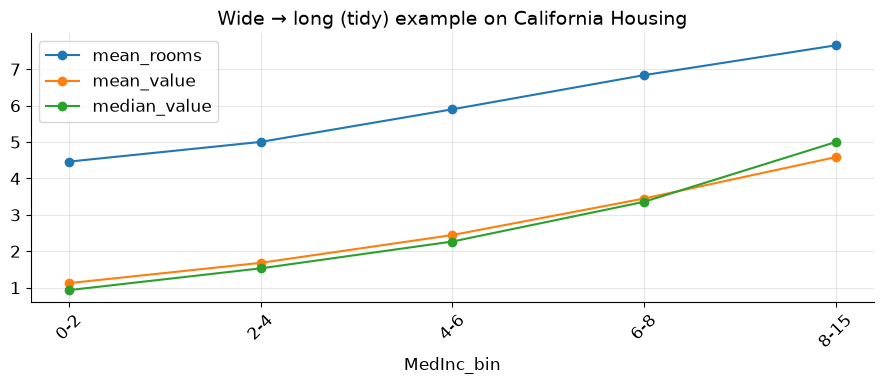

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for metric, sub in long.groupby("metric"):
    ax.plot(sub["MedInc_bin"].astype(str), sub["value"], marker="o", label=metric)

ax.set_xlabel("MedInc_bin")
ax.set_title("Wide → long (tidy) example on California Housing")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Expected output.** A line plot with three series (`mean_value`, `median_value`, `mean_rooms`) increasing across income bins — a compact visual summary that only works cleanly because the data is in long form.

- **Summary.** Prefer tidy (long) tables for analysis and plotting; use `melt` to go wide→long and `pivot`/`pivot_table` for the reverse.

## Core DataFrame operations

**Why it matters.** Most analyses reduce to a small number of primitives repeated in different orders: select, filter, mutate, sort, group, aggregate. Learning these fluently in pandas {cite}`mckinney2010pandas` lets you translate almost any research question into a few lines of code — and, later, the same idioms carry over to SQL and Polars.

Typical wrangling building blocks:

- **Select** — pick the columns you need (`df[[...]]`);
- **Filter** — keep the rows that match a predicate (`df[mask]`, `df.query(...)`);
- **Mutate** — add or overwrite columns (`df.assign(...)` or `df["new"] = ...`);
- **Sort** — `df.sort_values(by=..., ascending=...)`;
- **Group & aggregate** — `df.groupby(...).agg(...)`.

The cell below chains a select → filter → mutate to compute rooms-per-person for middle-income tracts. Note the `.copy()` calls: without them, subsequent assignments would raise `SettingWithCopyWarning`.

In [5]:
df_sel = df[["MedInc", "HouseAge", "AveRooms", "AveOccup", "MedHouseVal"]].copy()
df_filt = df_sel[df_sel["MedInc"].between(3, 6)].copy()
df_filt["rooms_per_person"] = df_filt["AveRooms"] / df_filt["AveOccup"]
df_filt.head()

,MedInc,HouseAge,AveRooms,AveOccup,MedHouseVal,rooms_per_person
3,5.6431,52.0,5.817352,2.547945,3.413,2.283154
4,3.8462,52.0,6.281853,2.181467,3.422,2.879646
5,4.0368,52.0,4.761658,2.139896,2.697,2.225182
6,3.6591,52.0,4.931907,2.128405,2.992,2.317185
7,3.1200,52.0,4.797527,1.788253,2.414,2.682800


### Grouping and aggregation

`groupby(...).agg(...)` is the workhorse of exploratory analysis. Using the *named-aggregation* syntax (`new_col=("input_col", "func")`) keeps output column names explicit and avoids the multi-level column indices that older pandas idioms produced.

**Expected output.** A five-row summary table (one per income bin) with mean/std of `MedHouseVal`, and mean `HouseAge` and `AveOccup`. `observed=True` ensures we only get bins that actually appear in the data — important when grouping on a `Categorical`.

- **Summary.** Select → filter → mutate → group → aggregate covers the majority of tabular transformations; use named aggregation for clean output.

In [6]:
summary = (
    df2.groupby("MedInc_bin", observed=True)
       .agg(
           mean_value=("MedHouseVal", "mean"),
           std_value=("MedHouseVal", "std"),
           mean_age=("HouseAge", "mean"),
           mean_occupancy=("AveOccup", "mean"),
       )
       .reset_index()
)
summary

,MedInc_bin,mean_value,std_value,mean_age,mean_occupancy
0,0-2,1.124972,0.715986,31.842898,3.168088
1,2-4,1.681993,0.845474,29.483558,2.927211
2,4-6,2.446352,0.941566,27.040873,3.095282
3,6-8,3.448447,0.937864,24.629187,3.011253
4,8-15,4.585956,0.687743,26.981279,4.873370


## Missing values (nulls)

**Definition.** A *missing value* is a cell whose true value is unknown
or unrecorded. In pandas, missing entries are usually `NaN` (float) or
`NA` (nullable dtypes); in SQL they are `NULL`. The label is uniform, but
the underlying *reason* is not.

**Why it matters.** {cite:t}`little2019statistical` formalise the
distinction between three missingness mechanisms — a taxonomy every
applied statistician should carry in working memory:

- **MCAR (Missing Completely At Random).** The probability of being
  missing is independent of both observed and unobserved values.
  Equivalent to a random subset of the data being erased. Under MCAR,
  complete-case analysis is unbiased (though less efficient); the
  mechanism is *ignorable*.
- **MAR (Missing At Random).** The probability of being missing depends
  only on *observed* variables. For example, older respondents may be
  more likely to skip an income question, but conditional on age the
  missingness is random. Multiple imputation and likelihood-based methods
  give unbiased estimates under MAR.
- **MNAR (Missing Not At Random).** The probability of being missing
  depends on the *unobserved* value itself — high earners refuse to
  disclose income *because* it is high. No general-purpose fix exists:
  you need a model of the missingness mechanism (selection model,
  pattern-mixture) and sensitivity analysis.

Recent work by {cite:t}`bertsimas2024impute` shows that jointly optimising
imputation and downstream prediction can outperform two-stage pipelines,
but even simple choices should be *deliberate*.

Two common pitfalls:

- **Silent row loss.** `dropna()` can quietly discard most of a dataset
  when several columns are sparsely populated. Always print row counts
  before and after.
- **Leakage via imputation.** Fitting the imputer (e.g. computing a
  median) on the full dataset before splitting into train/test leaks
  target information. Compute imputation statistics on the training set
  only.
- **Mean/median imputation biases variance downwards.** Replacing missing
  entries with a single central value shrinks within-column variance and
  attenuates estimated correlations. Multiple imputation preserves the
  correct uncertainty by drawing plausible values from a predictive
  distribution.

Below we inject 3% missing values into `AveRooms` and compare two
strategies: drop and median-impute.

In [7]:
df_missing = df.copy()
rng = np.random.default_rng(0)
mask = rng.random(len(df_missing)) < 0.03  # 3% missing
df_missing.loc[mask, "AveRooms"] = np.nan

df_missing.isna().mean().sort_values(ascending=False).head(10)

AveRooms       0.029409
MedInc         0.000000
HouseAge       0.000000
AveBedrms      0.000000
Population     0.000000
AveOccup       0.000000
Latitude       0.000000
Longitude      0.000000
MedHouseVal    0.000000
dtype: float64

In [8]:
dropped = df_missing.dropna(subset=["AveRooms"])
imputed = df_missing.copy()
imputed["AveRooms"] = imputed["AveRooms"].fillna(imputed["AveRooms"].median())

print("AveRooms missing (original):", df_missing["AveRooms"].isna().sum())
print("Rows after drop:", len(dropped))
print("AveRooms missing (imputed):", imputed["AveRooms"].isna().sum())

AveRooms missing (original): 607
Rows after drop: 20033
AveRooms missing (imputed): 0


**Expected output.** The dropped table has ~600 fewer rows than the original; the imputed table keeps every row but replaces `NaN`s with the column median. Either can be defensible; the choice should follow from the assumed missingness mechanism, not convenience.

- **Summary.** Detect missingness with `isna()`, decide on a strategy consistent with the missing-data mechanism, and always compare row counts before and after.

## Strings, regex, and dates

**Why it matters.** Real-world tabular data is rarely all-numeric. Identifiers, timestamps, and free-text fields require careful parsing before analysis. pandas exposes vectorised string operations via the `.str` accessor and datetime operations via `.dt`, both of which are dramatically faster (and safer) than Python `for` loops.

California Housing is numeric-only, so we synthesise realistic derived fields — tract codes and collection dates — and demonstrate:

- string formatting (zero-padded IDs);
- regex extraction with `.str.extract`;
- datetime parsing and calendar-component access (`.dt.day_name()`).

Two common pitfalls:

- **Silent timezone mixing.** Combining naive and tz-aware timestamps raises or, worse, coerces. Standardise on UTC internally.
- **Regex greediness.** `.*` will happily swallow neighbouring content; prefer explicit character classes or non-greedy matches.

In [9]:
df_str = df.reset_index(drop=False).rename(columns={"index": "row_id"}).copy()
df_str["tract_code"] = df_str["row_id"].map(lambda i: f"TRACT-{i:06d}-CA")
df_str["collection_date"] = pd.Timestamp("2024-01-01") + pd.to_timedelta(df_str["row_id"] % 180, unit="D")

df_str["tract_id"] = df_str["tract_code"].str.extract(r"TRACT-(\d+)-CA")[0].astype(int)
df_str["weekday"] = df_str["collection_date"].dt.day_name()

df_str[["tract_code", "tract_id", "collection_date", "weekday"]].head()

,tract_code,tract_id,collection_date,weekday
0,TRACT-000000-CA,0,2024-01-01,Monday
1,TRACT-000001-CA,1,2024-01-02,Tuesday
2,TRACT-000002-CA,2,2024-01-03,Wednesday
3,TRACT-000003-CA,3,2024-01-04,Thursday
4,TRACT-000004-CA,4,2024-01-05,Friday


```{hint}
Regex extraction is useful when keys encode structure (region codes, timestamps, product IDs, ...). Test your pattern on a handful of representative strings before applying it to millions of rows.
```

- **Summary.** Use `.str` and `.dt` accessors instead of Python loops; keep timezones consistent; test regexes on small samples first.

## Joining / merging tables

**Definition.** A *join* combines rows from two tables on one or more shared keys. pandas exposes joins through `pd.merge` (SQL-style) and `df.join` (index-based). The four core join types — `inner`, `left`, `right`, `outer` — differ in how they handle keys present in only one side.

**Why it matters.** Real datasets almost always come in *pieces* (fact tables plus lookup/dimension tables). Joins are how you enrich a working table with labels, hierarchies, or reference data. A join done wrong silently duplicates or drops rows.

Two common pitfalls:

- **Many-to-many blowup.** If the key is not unique on either side, the result is a Cartesian product per key value; pass `validate="one_to_many"` (etc.) to catch this early.
- **Coercion on the key.** If one side stores the key as `int` and the other as `str`, the join silently returns zero matches. Assert dtypes match before merging.

Below we build a small lookup table mapping income bins to human-readable labels and left-join it onto the summary table. The `assert` after the merge is a lightweight schema check — get into the habit of writing these.

In [10]:
bin_lookup = pd.DataFrame({
    "MedInc_bin": ["0-2", "2-4", "4-6", "6-8", "8-15"],
    "bin_label": ["low", "lower-mid", "mid", "upper-mid", "high"],
})

summary2 = summary.merge(bin_lookup, on="MedInc_bin", how="left")
assert summary2["bin_label"].isna().sum() == 0
summary2

,MedInc_bin,mean_value,std_value,mean_age,mean_occupancy,bin_label
0,0-2,1.124972,0.715986,31.842898,3.168088,low
1,2-4,1.681993,0.845474,29.483558,2.927211,lower-mid
2,4-6,2.446352,0.941566,27.040873,3.095282,mid
3,6-8,3.448447,0.937864,24.629187,3.011253,upper-mid
4,8-15,4.585956,0.687743,26.981279,4.873370,high


**Expected output.** The original five-row summary gains a `bin_label` column with human-readable descriptors (`low`, ..., `high`). Because the join is `left` and every bin has a matching entry in the lookup, no `NaN`s appear.

- **Summary.** Choose the join type deliberately, verify row counts before/after, and use `validate=` and `assert` to catch silent errors.

## SQL for tabular data (runnable with sqlite3)

**Why it matters.** SQL is the lingua franca of tabular data. Any real
data-science role will involve pulling data from a relational store at
some point, and much of what pandas does (`groupby`, `merge`, `filter`,
`sort`) has a direct SQL analogue. Knowing both keeps you productive
regardless of where the data lives; database systems also handle datasets
that would not fit in memory {cite}`kleppmann2017designing`.

**Declarative vs procedural.** SQL is a **declarative** language: you
specify *what* result you want (rows, groupings, aggregates) and leave
the *how* — join order, index usage, memory layout — to the query
optimiser. Pandas and Polars are, by contrast, largely **procedural**:
each `.groupby(...).agg(...)` call describes a concrete step and executes
immediately (though Polars' lazy API blurs the line). The declarative
style is what has kept SQL viable across five decades of hardware and
workload changes: an optimiser can rewrite the same query for a
single-node engine, a distributed warehouse, or a columnar store without
the analyst rewriting anything {cite}`kleppmann2017designing`. That
separation — between the *logical* description of a result and its
*physical* execution — is why SQL has been the dominant interface to
tabular data since Codd's 1970 relational model, and why every modern
data platform (BigQuery, Snowflake, DuckDB, Spark) eventually exposes a
SQL front-end.

We load a slice of the housing table into an in-memory SQLite database
and run a `GROUP BY` that mirrors the earlier pandas `groupby`. Comparing
the two APIs side-by-side is the fastest way to internalise the mapping
between them.

Two common pitfalls:

- **`NULL`s in `GROUP BY`.** SQL groups `NULL`s together and often
  excludes them from aggregates like `AVG`; pandas behaviour differs
  subtly. Handle explicitly.
- **String-templating queries.** Never `f"... {user_input} ..."` into
  SQL; use parameterised queries to avoid injection.

In [11]:
import sqlite3

conn = sqlite3.connect(":memory:")
df_sql = df[["MedInc", "AveRooms", "MedHouseVal"]].copy()
df_sql.to_sql("housing", conn, index=False, if_exists="replace")

query = '''
SELECT
  CASE
    WHEN MedInc < 2 THEN '0-2'
    WHEN MedInc < 4 THEN '2-4'
    WHEN MedInc < 6 THEN '4-6'
    WHEN MedInc < 8 THEN '6-8'
    ELSE '8-15'
  END AS MedInc_bin,
  COUNT(*) AS n,
  AVG(MedHouseVal) AS mean_value,
  AVG(AveRooms) AS mean_rooms
FROM housing
GROUP BY MedInc_bin
ORDER BY MedInc_bin
'''
pd.read_sql_query(query, conn)

,MedInc_bin,n,mean_value,mean_rooms
0,0-2,2439,1.125127,4.462049
1,2-4,10077,1.679210,5.002252
2,4-6,5751,2.443854,5.897238
3,6-8,1682,3.444522,6.836097
4,8-15,691,4.603707,7.743266


**Expected output.** Five rows — one per income bin — with the count, mean house value, and mean rooms. Numbers should be close (but not necessarily identical) to the pandas summary above; the small differences reflect how each engine handles bin boundaries.

- **Summary.** SQL and pandas cover overlapping ground; learning both lets you push work to whichever engine is best suited to the data's size and location.

## Polars (optional)

**Why it matters.** [Polars](https://pola.rs) is a modern DataFrame library built on Apache Arrow and Rust. It offers a lazy evaluation engine and often runs an order of magnitude faster than pandas on medium-sized datasets, while its expression API forces cleaner, more explicit code. Polars is not a required tool for this course, but it is increasingly common in industry pipelines and worth being aware of.

The cell below wraps the demo in a `try`/`except` so the notebook still executes when Polars is not installed. If it is available, notice how the transformation is composed via `.with_columns(...)` and `.group_by(...).agg([...])` — the same primitives as pandas, but with a stricter, more query-like feel.

- **Summary.** pandas remains the default; consider Polars (or DuckDB) when the data is large enough that pandas becomes the bottleneck.

In [12]:
try:
    import polars as pl

    pl_df = pl.from_pandas(df[["MedInc", "AveRooms", "MedHouseVal"]])

    out = (
        pl_df
        .with_columns([
            pl.when(pl.col("MedInc") < 2).then(pl.lit("0-2"))
              .when(pl.col("MedInc") < 4).then(pl.lit("2-4"))
              .when(pl.col("MedInc") < 6).then(pl.lit("4-6"))
              .when(pl.col("MedInc") < 8).then(pl.lit("6-8"))
              .otherwise(pl.lit("8-15"))
              .alias("MedInc_bin")
        ])
        .group_by("MedInc_bin")
        .agg([
            pl.len().alias("n"),
            pl.mean("MedHouseVal").alias("mean_value"),
            pl.mean("AveRooms").alias("mean_rooms"),
        ])
        .sort("MedInc_bin")
    )
    display(out)
except Exception as e:
    print("Polars not available; skipping optional demo.")
    print("Install with: pip install polars")

Polars not available; skipping optional demo.
Install with: pip install polars


## Data formats: CSV vs Parquet

**Why it matters.** How you *store* data has a direct effect on how fast
(and cheaply) you can *read* it. CSV is human-readable and universal,
but it stores everything as text: no dtypes, no compression, no
column-level access. Parquet is a columnar, compressed, binary format
that is dramatically faster to read for analytics workloads, especially
when you only need a subset of columns.

**Columnar layout and predicate pushdown.** A CSV file stores rows
contiguously: reading a single column still requires the reader to walk
every byte of every row. Parquet flips the layout — values from the same
column are stored together in *column chunks*, each with its own
dictionary encoding, run-length compression, and per-chunk statistics
(min, max, null count). Two consequences follow that matter for
analytical workloads {cite}`kleppmann2017designing`:

- **Projection pushdown.** Reading `SELECT price FROM housing` from a
  Parquet file touches only the `price` column chunks; the other columns
  are never decoded. On wide tables this is often an order-of-magnitude
  speed-up.
- **Predicate pushdown.** The per-chunk min/max statistics let the reader
  *skip* entire chunks whose range cannot satisfy a `WHERE` clause (e.g.
  `WHERE year = 2024` skips chunks whose max year is 2023). Combined
  with partitioning on frequently filtered columns, this pushes filter
  work down to the storage layer.

Together, columnar layout and pushdown are why Parquet, ORC, and
Arrow-backed formats dominate modern analytical stacks — the same
principle underlies column-store databases like ClickHouse and DuckDB.

Rough rules of thumb:

- Use **CSV** for interchange with non-technical stakeholders, tiny
  files, and one-off imports.
- Use **Parquet** for anything you will read more than once, anything
  above a few MB, and anything with a stable schema.
- Use **Arrow IPC/Feather** for zero-copy interchange between Python, R,
  and analytical databases (DuckDB, Polars).

Two common pitfalls:

- **Missing engine.** `pandas.to_parquet` requires `pyarrow` or
  `fastparquet`; the cell below fails gracefully if neither is installed.
- **Schema drift on append.** Concatenating Parquet files with mismatched
  dtypes silently coerces or errors depending on the engine — validate
  schemas explicitly.

In [13]:
import os
import tempfile

tmpdir = tempfile.TemporaryDirectory()
parquet_path = os.path.join(tmpdir.name, "housing_sample.parquet")

sample = df.head(5000)

try:
    sample.to_parquet(parquet_path, index=False)
    restored = pd.read_parquet(parquet_path)
    print("Parquet round-trip OK:", restored.shape)
    restored.head()
except Exception as e:
    print("Parquet not available here. Install `pyarrow` (recommended).")
    print("Error:", repr(e))

Parquet not available here. Install `pyarrow` (recommended).
Error: ImportError("Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.\nA suitable version of pyarrow or fastparquet is required for parquet support.\nTrying to import the above resulted in these errors:\n - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.\n - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.")


**Expected output.** If `pyarrow` is installed, the round-trip prints `Parquet round-trip OK: (5000, 9)`; otherwise an informative error explains what to install. The point is not the round-trip itself but that formats are *choices*, and the choice should be justified.

- **Summary.** Prefer Parquet for repeated analytical reads; keep CSV for interchange with humans and legacy tools.

## Exercises

Work through the following exercises using the California Housing dataset (`df = load_california_housing()`). Each exercise is self-contained; try them in a fresh notebook or in the space below.

:::{admonition} Exercise 2.1 — Reshape wide→long for a different feature
:class: exercise
Build a wide summary of `AveOccup` (mean and standard deviation) grouped by a binned version of `HouseAge` (use four bins: 0-10, 10-25, 25-40, 40-52). Then melt the summary into a long table with columns `HouseAge_bin`, `metric`, `value` and plot both metrics as lines against `HouseAge_bin`. Comment on any pattern you see.
:::

:::{admonition} Exercise 2.2 — Merge on two lookup tables
:class: exercise
Create two lookup tables:

1. `income_lookup` mapping each `MedInc_bin` (`0-2`, ..., `8-15`) to a *policy tier* (`"subsidy"`, `"neutral"`, `"tax"`).
2. `region_lookup` mapping a coarse latitude band (`Latitude < 34`, `34 ≤ Latitude < 37`, `Latitude ≥ 37`) to a *region name* (`"South"`, `"Central"`, `"North"`).

Left-join both onto the tract-level table and produce a summary of mean `MedHouseVal` broken down by `(region, policy_tier)`. Verify with `validate="many_to_one"` on each merge that no row-count blow-up occurs.
:::

:::{admonition} Exercise 2.3 — SQL query on the in-memory database
:class: exercise
Using the SQLite connection from Section 9, write a single SQL query that returns, for each `MedInc_bin`, the number of tracts, the mean `MedHouseVal`, and the ratio `mean(MedHouseVal) / mean(AveRooms)` — sorted from lowest to highest ratio. Confirm your result matches an equivalent pandas expression.
:::

:::{tip}
Sample solutions will be discussed in the practical session. Focus on writing readable, well-commented code — clarity now saves debugging time later {cite}`kernighan1999practice`.
:::

:::{admonition} Key Takeaways
:class: important
- Git is the foundation of collaborative, reproducible data science {cite}`wilson2017good`
- pandas provides a powerful grammar for tabular data manipulation {cite}`mckinney2010pandas`; the same primitives recur in SQL and Polars
- Tidy data {cite}`wickham2014tidy` — variables in columns, observations in rows — removes downstream friction
- Missing values are not neutral: match the imputation strategy to the missingness mechanism {cite}`little2019statistical`
- Always inspect data before modelling — shape, types, missing values, duplicates
- Choose data formats (Parquet over CSV for repeated reads) based on the workflow, not habit
:::

**Next.** [Lecture 3](lecture_3.ipynb) turns to *data retrieval* — where the data comes from in the first place (APIs, web scraping, databases) and how to bring it in reproducibly. Come back to this notebook as a wrangling reference throughout the course.